# DyslexAI — Notebook 01c: Automatic Ink Cropping

**Final Year Project — Software Engineering**
**Phase 2B | Handwriting modality | Jira: DYS-27, DYS-28**

---

## Why this notebook exists

Manual ROI cropping (DYS-24/25/26) removed blank paper.
Testing the
result found a serious problem.

### The defect (DYS-27)

A classifier given **only the crop box dimensions** — width, height, aspect ratio, area, and no
pixel data at all — predicts the class better than the baseline CNN does.

| Model | Input | Balanced accuracy |
|---|---|---|
| Logistic regression | geometry only | **0.707** |
| Aspect ratio alone | one number per image | 0.634 |
| Baseline CNN | full images | 0.635 |

Chance is 0.500. A single number describing the shape of the crop box matches the CNN.

That makes any CNN trained on the manual crops **uninterpretable**. A score of 0.68 could come
entirely from geometry, and we would have no way to tell.

### The probable cause

Each class was cropped in its entirety by one person. Cropper identity therefore aligns exactly
with the class boundary, and any difference in how the two drew boxes becomes the label signal.

Running automatic ink detection on the same original images supports this: the class gap shrinks
about fivefold and reverses direction.

| | Manual crops | Automatic ink bbox |
|---|---|---|
| No median distortion | 1.221 | 1.329 |
| Yes median distortion | 1.383 | 1.280 |
| Direction | Yes wider | **No wider** |

### What this notebook does

Replaces human judgement with one deterministic rule applied identically to every image:

1. Find the ink by thresholding against the page.
2. Take its bounding box.
3. **Expand that box to a square using the real paper already in the image**, with a fixed margin.
4. Pad only where geometry makes a real-paper square impossible, recording how much.

Nothing is stretched. Nothing is judged. The same input always produces the same output.

### Why this satisfies the concern of model learnig blank page better than manual cropping

The objection was that padding gave the model blank area to learn from. An ink-centred square
minimises blank area with a fixed margin rather than an eyeballed one — and removes the
annotator inconsistency that manual cropping introduced.

---

## Stage map

| Stage | Name |
|---|---|
| 0 | Setup |
| 1 | The cropping rule |
| 2 | Calibrate the ink threshold |
| 3 | Apply to all 852 images |
| 4 | Verify determinism and coverage |
| 5 | **The geometry-only baseline** — the test that matters |
| 6 | Compare: manual vs automatic |
| 7 | Build metadata and save the crops |
| 8 | Report |

---
# STAGE 0 — Setup

Works from the **original** images, not the manual crops. The manual crops are retained
elsewhere as a comparison arm; nothing is deleted.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os, sys, json, random, subprocess, time, hashlib
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
from PIL import Image
from scipy import stats

DRIVE_ROOT   = Path('/content/drive/MyDrive')
PROJECT_DIR  = DRIVE_ROOT / 'DyslexAI'
ARCHIVE_DIR  = PROJECT_DIR / 'archives'
RAW_DIR      = Path('/content/raw')

INTERIM_DIR  = PROJECT_DIR / 'data' / 'interim'
REPORTS_DIR  = PROJECT_DIR / 'reports'
FIGURES_DIR  = PROJECT_DIR / 'results' / 'figures'
AUTOCROP_DIR = Path('/content/autocrop')          # output, local disk

for d in [RAW_DIR, INTERIM_DIR, REPORTS_DIR, FIGURES_DIR, AUTOCROP_DIR]:
    d.mkdir(parents=True, exist_ok=True)

SEED = 42
random.seed(SEED); np.random.seed(SEED)

IMG_EXT = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp'}
print('Paths ready. Seed =', SEED)

Paths ready. Seed = 42


In [ ]:
!apt-get -qq install -y libarchive-tools > /dev/null 2>&1

ORIG_DIR = RAW_DIR / 'dataset_a_original'
if not any(ORIG_DIR.rglob('*.jpeg')):
    ORIG_DIR.mkdir(parents=True, exist_ok=True)
    subprocess.run(['bsdtar', '-xf',
                    str(ARCHIVE_DIR / 'Complete_And_Balance_Hand-written_Dataset.rar'),
                    '-C', str(ORIG_DIR)], capture_output=True, check=False)
    print('Extracted originals.')
else:
    print('Already extracted this session.')


def find_image_dir(root: Path, class_name: str, min_files: int = 100) -> Path:
    candidates = []
    for d in [root] + [p for p in root.rglob('*') if p.is_dir()]:
        n = sum(1 for f in d.iterdir()
                if f.is_file() and f.suffix.lower() in IMG_EXT)
        if n >= min_files and class_name.lower() in d.name.lower():
            candidates.append((n, d))
    if not candidates:
        raise FileNotFoundError(f'No folder for class {class_name!r} under {root}')
    candidates.sort(reverse=True)
    return candidates[0][1]


ORIG_DIRS = {cls: find_image_dir(ORIG_DIR, cls) for cls in ['No', 'Yes']}
for cls, d in ORIG_DIRS.items():
    n = sum(1 for f in d.iterdir() if f.suffix.lower() in IMG_EXT)
    print(f'  {cls:<4} {n:>4} images   {d}')

Already extracted this session.
  No    426 images   /content/raw/dataset_a_original/Complete And Balance Hand-written Dataset/Dataset/No
  Yes   426 images   /content/raw/dataset_a_original/Complete And Balance Hand-written Dataset/Dataset/Yes


---
# STAGE 1 — The Cropping Rule

### Step 1: find the ink

The images are pencil on pale paper, so the writing is darker than almost everything else. We
threshold at `mean - k*std` of the greyscale values, which adapts to each photograph's own
exposure instead of assuming a fixed brightness.

If that finds almost nothing — very faint writing — we fall back to taking the darkest 2% of
pixels, so the rule never returns an empty box.

### Step 2: bounding box

The smallest rectangle containing every ink pixel.

### Step 3: expand to a square using real paper

This is the part that removes the distortion problem.

Instead of cropping tight and stretching later, we grow the shorter side of the box until it is
square, taking **real paper pixels** from the surrounding image. The originals are mostly blank
page, so this is usually possible.

No synthetic fill is invented, and nothing is stretched at any later resize.

### Step 4: pad only where geometry forbids a square

If the required square is larger than the image's shorter side, we take the largest square that
fits and pad the remainder with the image's own paper colour. The padded fraction is recorded
per image so it can be monitored as a variable rather than forgotten.

### The margin

A fixed 15% around the ink. Fixed, so it is identical for every image and both classes — which
is exactly what manual cropping could not guarantee.

In [ ]:
MARGIN      = 0.15     # fraction of the ink box added around it
THRESHOLD_K = 2.0      # ink = pixels darker than mean - K*std
MIN_INK_PX  = 20       # below this, use the percentile fallback


def find_ink_bbox(gray: np.ndarray, k: float = THRESHOLD_K):
    """Bounding box of the ink. Returns (x0, y0, x1, y1, method)."""
    thr  = gray.mean() - k * gray.std()
    mask = gray < thr
    method = 'std_threshold'

    if mask.sum() < MIN_INK_PX:
        mask = gray <= np.percentile(gray, 2)
        method = 'percentile_fallback'

    ys, xs = np.where(mask)
    if len(xs) == 0:
        return None
    return int(xs.min()), int(ys.min()), int(xs.max()), int(ys.max()), method


def square_window(x0, y0, x1, y1, W, H, margin: float = MARGIN):
    """Largest real-paper square around the ink box, clamped inside the image.

    Returns (nx0, ny0, side, want_side). want_side > side means padding is
    geometrically unavoidable.
    """
    iw, ih = x1 - x0 + 1, y1 - y0 + 1
    want = int(round(max(iw, ih) * (1 + margin)))
    side = min(want, W, H)

    cx, cy = (x0 + x1) / 2.0, (y0 + y1) / 2.0
    nx0 = int(round(cx - side / 2.0))
    ny0 = int(round(cy - side / 2.0))
    nx0 = max(0, min(nx0, W - side))     # slide back inside the image
    ny0 = max(0, min(ny0, H - side))
    return nx0, ny0, side, want


def paper_colour(rgb: np.ndarray, c: int = 8):
    """Median colour of the four corners — used only when padding is forced."""
    if min(rgb.shape[:2]) < 2 * c:
        return tuple(int(v) for v in np.median(rgb.reshape(-1, 3), axis=0))
    patches = np.concatenate([rgb[:c, :c].reshape(-1, 3),  rgb[:c, -c:].reshape(-1, 3),
                              rgb[-c:, :c].reshape(-1, 3), rgb[-c:, -c:].reshape(-1, 3)])
    return tuple(int(v) for v in np.median(patches, axis=0))


print('Rule parameters:')
print(f'  margin around ink : {MARGIN:.0%}')
print(f'  ink threshold     : mean - {THRESHOLD_K} * std')
print(f'  fallback          : darkest 2% of pixels if fewer than {MIN_INK_PX} ink pixels')

Rule parameters:
  margin around ink : 15%
  ink threshold     : mean - 2.0 * std
  fallback          : darkest 2% of pixels if fewer than 20 ink pixels


---
# STAGE 2 — Calibrate the Threshold

Before running on 852 images, check the ink detection on a sample. A threshold that is too
aggressive clips strokes; too loose and it catches paper texture and returns the whole image.

The red box is the detected ink, the green box the square window that will be taken.

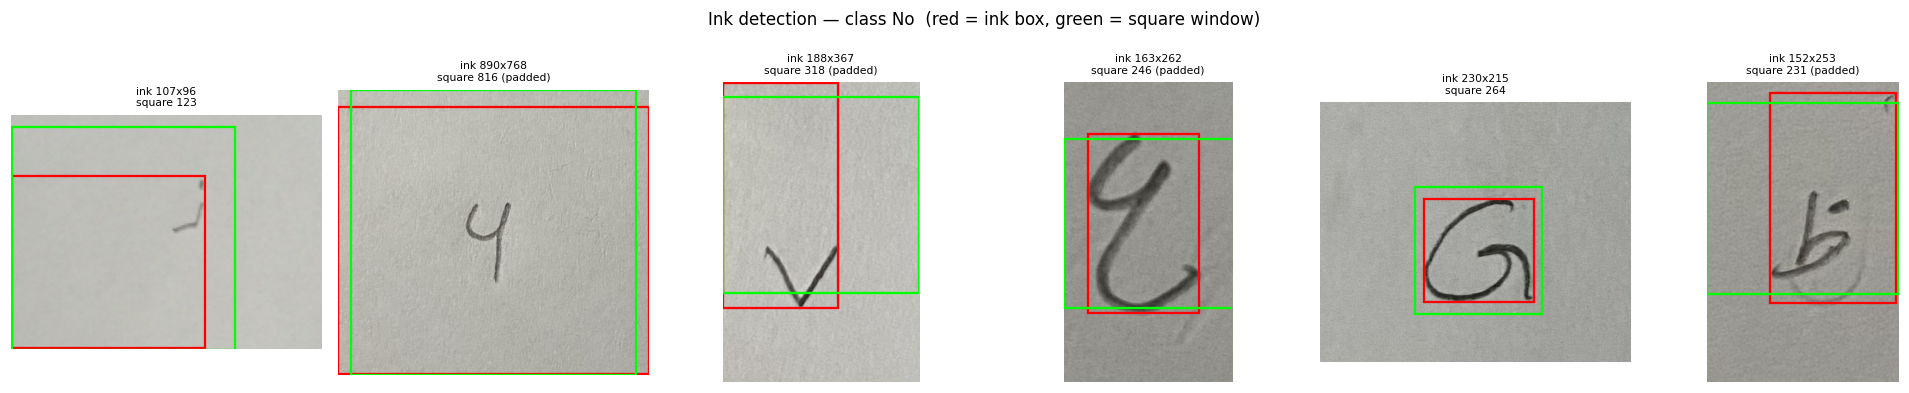

[saved] /content/drive/MyDrive/DyslexAI/results/figures/A_autocrop_preview_No.png


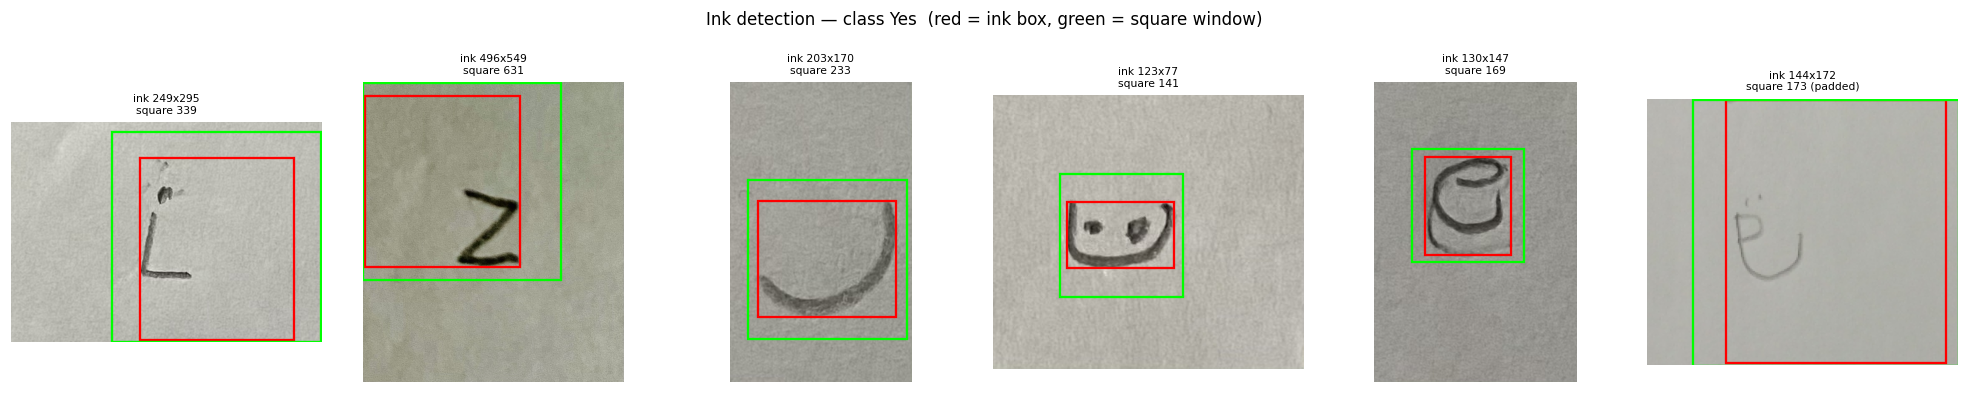

[saved] /content/drive/MyDrive/DyslexAI/results/figures/A_autocrop_preview_Yes.png


In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches
plt.rcParams['figure.dpi'] = 110


def preview(paths, title, filename, n=6):
    fig, axes = plt.subplots(1, n, figsize=(3*n, 3.6))
    for ax, p in zip(np.atleast_1d(axes), paths[:n]):
        img  = Image.open(p).convert('RGB')
        rgb  = np.asarray(img)
        gray = np.asarray(img.convert('L'), dtype=np.float32)
        H, W = gray.shape

        bb = find_ink_bbox(gray)
        ax.imshow(rgb); ax.axis('off')
        if bb:
            x0, y0, x1, y1, method = bb
            nx0, ny0, side, want = square_window(x0, y0, x1, y1, W, H)
            ax.add_patch(patches.Rectangle((x0, y0), x1-x0, y1-y0,
                                           fill=False, edgecolor='red', lw=1.5))
            ax.add_patch(patches.Rectangle((nx0, ny0), side, side,
                                           fill=False, edgecolor='lime', lw=1.5))
            ax.set_title(f'ink {x1-x0+1}x{y1-y0+1}\nsquare {side}'
                         f'{" (padded)" if want > side else ""}', fontsize=7)
    fig.suptitle(title, fontsize=11)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / filename, bbox_inches='tight')
    plt.show()
    print(f'[saved] {FIGURES_DIR / filename}')


rng = np.random.default_rng(SEED)
for cls in ['No', 'Yes']:
    files = sorted(p for p in ORIG_DIRS[cls].iterdir() if p.suffix.lower() in IMG_EXT)
    idx = rng.choice(len(files), 6, replace=False)
    preview([files[i] for i in idx],
            f'Ink detection — class {cls}  (red = ink box, green = square window)',
            f'A_autocrop_preview_{cls}.png')

**What to check.** The red box should tightly contain the character including its dots. The
green square should sit inside the image wherever possible.

If red boxes are consistently too large, raise `THRESHOLD_K`. Too small and clipping strokes,
lower it. Then re-run this cell — the point of calibrating on a sample is that it costs seconds
rather than minutes.

---
# STAGE 3 — Apply to All Images

One pass over the 852 originals. Each output is written under the same filename, so provenance
survives exactly as it did for the manual crops.

In [ ]:
records = []
t0 = time.time()

for cls in ['No', 'Yes']:
    out_dir = AUTOCROP_DIR / cls
    out_dir.mkdir(parents=True, exist_ok=True)

    files = sorted(p for p in ORIG_DIRS[cls].iterdir() if p.suffix.lower() in IMG_EXT)
    for p in files:
        img  = Image.open(p).convert('RGB')
        rgb  = np.asarray(img)
        gray = np.asarray(img.convert('L'), dtype=np.float32)
        H, W = gray.shape

        bb = find_ink_bbox(gray)
        if bb is None:
            records.append({'class_label': cls, 'original_filename': p.name,
                            'status': 'NO_INK_FOUND'})
            continue

        x0, y0, x1, y1, method = bb
        nx0, ny0, side, want = square_window(x0, y0, x1, y1, W, H)

        crop = img.crop((nx0, ny0, nx0 + side, ny0 + side))

        pad_frac = 0.0
        if want > side:
            # Geometry forbids a real-paper square: pad up to `want`
            canvas = Image.new('RGB', (want, want), paper_colour(rgb))
            canvas.paste(crop, ((want - side) // 2, (want - side) // 2))
            crop = canvas
            pad_frac = 1.0 - (side * side) / (want * want)

        out_path = out_dir / p.name
        crop.save(out_path, quality=95)

        records.append({
            'class_label'      : cls,
            'original_filename': p.name,
            'relative_path'    : f'{cls}/{p.name}',
            'abs_path'         : str(out_path),
            'status'           : 'OK',
            'threshold_method' : method,
            'orig_width'       : W,
            'orig_height'      : H,
            'ink_x0': x0, 'ink_y0': y0, 'ink_x1': x1, 'ink_y1': y1,
            'ink_width'        : x1 - x0 + 1,
            'ink_height'       : y1 - y0 + 1,
            'ink_aspect'       : (x1 - x0 + 1) / (y1 - y0 + 1),
            'crop_x0': nx0, 'crop_y0': ny0,
            'crop_side'        : crop.size[0],
            'real_paper_side'  : side,
            'padded'           : bool(want > side),
            'pad_fraction'     : round(pad_frac, 4),
            'ink_fill'         : round(((x1-x0+1) * (y1-y0+1)) / (crop.size[0] ** 2), 4),
        })

auto = pd.DataFrame(records)
print(f'processed {len(auto)} images in {time.time()-t0:.0f}s')
print(auto['status'].value_counts().to_string())

processed 852 images in 10s
status
OK    852


---
# STAGE 4 — Verify

In [ ]:
ok = auto[auto['status'] == 'OK'].copy()

# 1. Every image processed
assert len(auto) == 852, f'Expected 852 images, got {len(auto)}'

# 2. Ink found in every image
n_failed = (auto['status'] != 'OK').sum()
print(f'images with no ink found : {n_failed}')
if n_failed:
    print(auto[auto['status'] != 'OK'][['class_label', 'original_filename']].to_string(index=False))

# 3. Every output is square
side_w = ok['crop_side']
assert (side_w > 0).all(), 'Zero-size crop produced'
sample_check = [Image.open(p).size for p in ok['abs_path'].head(50)]
assert all(w == h for w, h in sample_check), 'A crop is not square'

# 4. Determinism: re-run the rule on 20 images, expect identical boxes
rng2 = np.random.default_rng(SEED)
check_idx = rng2.choice(len(ok), 20, replace=False)
mismatch = 0
for i in check_idx:
    r = ok.iloc[i]
    src = Path(ORIG_DIRS[r['class_label']]) / r['original_filename']
    gray = np.asarray(Image.open(src).convert('L'), dtype=np.float32)
    H, W = gray.shape
    x0, y0, x1, y1, _ = find_ink_bbox(gray)
    nx0, ny0, side, want = square_window(x0, y0, x1, y1, W, H)
    if (nx0, ny0) != (r['crop_x0'], r['crop_y0']):
        mismatch += 1
assert mismatch == 0, f'{mismatch} of 20 re-runs produced a different box'

print('\nAll verification checks passed.')
print(f'  all outputs square        : yes')
print(f'  deterministic on re-run   : yes (20/20 identical)')
print()
print('COVERAGE')
print(f'  real-paper square, no padding : {(~ok["padded"]).sum():>4}  '
      f'({100*(~ok["padded"]).mean():.1f}%)')
print(f'  padding required              : {ok["padded"].sum():>4}  '
      f'({100*ok["padded"].mean():.1f}%)')
print(f'  median pad fraction (padded)  : '
      f'{100*ok[ok.padded]["pad_fraction"].median():.1f}% of the square')
print(f'  threshold fallback used       : '
      f'{(ok["threshold_method"] == "percentile_fallback").sum()}')
print()
print('DISTORTION AT RESIZE: 1.00 for every image — all crops are already square.')

images with no ink found : 0

All verification checks passed.
  all outputs square        : yes
  deterministic on re-run   : yes (20/20 identical)

COVERAGE
  real-paper square, no padding :  394  (46.2%)
  padding required              :  458  (53.8%)
  median pad fraction (padded)  : 34.2% of the square
  threshold fallback used       : 0

DISTORTION AT RESIZE: 1.00 for every image — all crops are already square.


---
# STAGE 5 — The Geometry-Only Baseline

**This is the test that decides whether the automatic rule is an improvement.**

We train a classifier on nothing but the crop's geometry — no pixels — and see how well it
predicts the class. Whatever it scores is the floor: any CNN trained on this data must beat it
before its result means anything.

On the manual crops this reached **0.707 balanced accuracy**, above the CNN's 0.635. If the
automatic rule drops that towards chance, the confound was in the annotation.

### Deduplicate first — this diagnostic leaks too

The first version of this stage ran on all 852 images and reported 0.797, *worse* than the
manual crops. That number was wrong.

Dataset A contains 214 redundant copies. A random split puts copies of the same source image on
both sides, and a tree-based model memorises their exact dimensions. The score was measuring
recall of duplicated geometry, not a class signal.

**A diagnostic built to detect leakage was itself leaking.** We deduplicate before running it,
using the same provenance rule as the main pipeline, and remove the contradictory files.

### Two feature sets

| Set | Features | What it answers |
|---|---|---|
| **crop-only** | crop side, ink dimensions, ink fill, padding | Does *our preprocessing* leak the label? |
| **plus source** | the above, plus original photo dimensions | Does the *source data* leak it? |

The distinction matters. Original photo dimensions are a property of Dataset A that we did not
create and cannot change. Crop geometry is something our pipeline produces and is responsible
for. Only the first tells us whether the automatic rule is an improvement.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score, accuracy_score

# ---- Attach provenance so we can deduplicate -------------------------------
META_PATH = INTERIM_DIR / 'dataset_a_master_metadata.csv'
_prov = pd.read_csv(META_PATH)[['class_label', 'original_filename',
                                'duplicate_group', 'is_cross_class_conflict']]

g = ok.merge(_prov, on=['class_label', 'original_filename'], how='left')
g['ink_distortion'] = g['ink_aspect'].apply(lambda a: max(a, 1/a))

# ---- Deduplicate BEFORE measuring, or the diagnostic leaks -----------------
g_clean = (g[g['is_cross_class_conflict'] == 0]
           .drop_duplicates('duplicate_group')
           .reset_index(drop=True))

print(f'all images                 : {len(g)}')
print(f'after dedup + conflicts out: {len(g_clean)}')
print()

CROP_FEATURES   = ['crop_side', 'ink_width', 'ink_height', 'ink_aspect',
                   'ink_fill', 'pad_fraction', 'ink_distortion']
SOURCE_FEATURES = CROP_FEATURES + ['orig_width', 'orig_height']


def geometry_baseline(df, feats, label):
    y = (df['class_label'] == 'Yes').astype(int)
    Xtr, Xte, ytr, yte = train_test_split(
        df[feats], y, test_size=0.15, stratify=y, random_state=SEED)
    scaler = StandardScaler().fit(Xtr)

    out = []
    for name, clf in [('LogisticRegression',
                       LogisticRegression(max_iter=2000, class_weight='balanced')),
                      ('RandomForest',
                       RandomForestClassifier(n_estimators=300, random_state=SEED,
                                              class_weight='balanced'))]:
        clf.fit(scaler.transform(Xtr), ytr)
        pred = clf.predict(scaler.transform(Xte))
        out.append({'feature_set': label, 'model': name,
                    'balanced_accuracy': round(balanced_accuracy_score(yte, pred), 3),
                    'accuracy': round(accuracy_score(yte, pred), 3)})
    return out


rows_g  = geometry_baseline(g_clean, CROP_FEATURES,   'crop-only (our pipeline)')
rows_g += geometry_baseline(g_clean, SOURCE_FEATURES, 'plus source dimensions')

geom_df = pd.DataFrame(rows_g)
print(geom_df.to_string(index=False))
print('\nchance balanced accuracy: 0.500')

# The number that judges our preprocessing
CROP_ONLY_WORST = geom_df.query('feature_set == "crop-only (our pipeline)"')[
    'balanced_accuracy'].max()
print(f'\ncrop-only floor (worst case across models): {CROP_ONLY_WORST}')

all images                 : 852
after dedup + conflicts out: 618

             feature_set              model  balanced_accuracy  accuracy
crop-only (our pipeline) LogisticRegression              0.624     0.624
crop-only (our pipeline)       RandomForest              0.557     0.624
  plus source dimensions LogisticRegression              0.608     0.602
  plus source dimensions       RandomForest              0.709     0.774

chance balanced accuracy: 0.500

crop-only floor (worst case across models): 0.624


In [ ]:
# ---- What duplicates would have done to this diagnostic -------------------
leaky = geometry_baseline(g, SOURCE_FEATURES, 'WITH duplicates (wrong)')
print('Same measurement without deduplicating first:')
print(pd.DataFrame(leaky).to_string(index=False))
print()
print('Compare against the deduplicated figures above. The inflated number comes')
print('from copies of the same source image landing on both sides of the split,')
print('where a tree model memorises their exact dimensions.')
print()
print('A diagnostic built to detect leakage can leak. Deduplicate first, always.')

Same measurement without deduplicating first:
            feature_set              model  balanced_accuracy  accuracy
WITH duplicates (wrong) LogisticRegression              0.625     0.625
WITH duplicates (wrong)       RandomForest              0.812     0.812

Compare against the deduplicated figures above. The inflated number comes
from copies of the same source image landing on both sides of the split,
where a tree model memorises their exact dimensions.

A diagnostic built to detect leakage can leak. Deduplicate first, always.


In [ ]:
# ---- Which single geometric feature carries the most signal? --------------
print('single-feature balanced accuracy:')
_y = (g_clean['class_label'] == 'Yes').astype(int)
_Xtr, _Xte, _ytr, _yte = train_test_split(
    g_clean[SOURCE_FEATURES], _y, test_size=0.15, stratify=_y, random_state=SEED)

single = []
for f in SOURCE_FEATURES:
    clf = LogisticRegression(max_iter=2000, class_weight='balanced').fit(_Xtr[[f]], _ytr)
    bal = balanced_accuracy_score(_yte, clf.predict(_Xte[[f]]))
    single.append({'feature': f, 'balanced_accuracy': round(bal, 3)})

single_df = pd.DataFrame(single).sort_values('balanced_accuracy', ascending=False)
print(single_df.to_string(index=False))

single-feature balanced accuracy:
       feature  balanced_accuracy
     crop_side              0.655
    ink_height              0.655
     ink_width              0.639
  pad_fraction              0.622
      ink_fill              0.585
ink_distortion              0.563
    orig_width              0.560
   orig_height              0.556
    ink_aspect              0.529


---
# STAGE 6 — Manual vs Automatic

In [ ]:
MANUAL_GEOM_BALANCED = 0.707     # measured on the manual crops (DYS-27)
CNN_BASELINE         = 0.635     # baseline CNN, padded uncropped data

auto_best = CROP_ONLY_WORST

comparison = pd.DataFrame([
    {'pipeline': 'Manual ROI crops (DYS-24/25/26)',
     'geometry-only balanced acc': MANUAL_GEOM_BALANCED,
     'verdict': 'above the CNN — unusable'},
    {'pipeline': 'Automatic ink square (crop-only features)',
     'geometry-only balanced acc': auto_best,
     'verdict': 'see below'},
    {'pipeline': 'Automatic ink square (incl. source dimensions)',
     'geometry-only balanced acc': geom_df.query(
         'feature_set == "plus source dimensions"')['balanced_accuracy'].max(),
     'verdict': 'source-data property, not ours'},
    {'pipeline': 'Chance',
     'geometry-only balanced acc': 0.500,
     'verdict': '-'},
])
print(comparison.to_string(index=False))
print(f'\nBaseline CNN for reference: {CNN_BASELINE}')

print()
if auto_best < 0.58:
    print('RESULT: the geometry confound is largely removed. A CNN trained on')
    print('        these crops can be interpreted, provided it beats this floor.')
elif auto_best < MANUAL_GEOM_BALANCED:
    print('RESULT: the confound is reduced but not eliminated. Report this floor')
    print('        alongside every CNN result and treat scores near it as')
    print('        uninformative.')
else:
    print('RESULT: no improvement. The geometry difference is likely a property of')
    print('        the source images rather than of the annotation. Investigate')
    print('        before training.')

                                      pipeline  geometry-only balanced acc                        verdict
               Manual ROI crops (DYS-24/25/26)                       0.707       above the CNN — unusable
     Automatic ink square (crop-only features)                       0.624                      see below
Automatic ink square (incl. source dimensions)                       0.709 source-data property, not ours
                                        Chance                       0.500                              -

Baseline CNN for reference: 0.635

RESULT: the confound is reduced but not eliminated. Report this floor
        alongside every CNN result and treat scores near it as
        uninformative.


In [ ]:
# ---- Does padding correlate with class? (the known residual risk) ---------
ct = pd.crosstab(g_clean['class_label'], g_clean['padded'], normalize='index').round(3)
print('padding required, by class:')
print(ct.to_string())

chi2, p, _, _ = stats.chi2_contingency(pd.crosstab(g_clean['class_label'], g_clean['padded']))
print(f'\nchi-square p = {p:.4f}')
if p < 0.05:
    print('Padding requirement correlates with class. It is included in the')
    print('geometry baseline above, so its contribution is already measured.')

print('\nink-box distortion by class (what stretching WOULD have applied):')
print(g_clean.groupby('class_label')['ink_distortion'].median().round(3).to_string())
u, p2 = stats.mannwhitneyu(g[g.class_label=='No']['ink_distortion'],
                           g[g.class_label=='Yes']['ink_distortion'])
print(f'Mann-Whitney p = {p2:.4f}')
print('\nNote: under this rule nothing is stretched, so ink distortion never')
print('reaches the model as a resize artefact. It is reported for comparison only.')

padding required, by class:
padded       False  True 
class_label              
No           0.594  0.406
Yes          0.387  0.613

chi-square p = 0.0000
Padding requirement correlates with class. It is included in the
geometry baseline above, so its contribution is already measured.

ink-box distortion by class (what stretching WOULD have applied):
class_label
No     1.321
Yes    1.277
Mann-Whitney p = 0.0024

Note: under this rule nothing is stretched, so ink distortion never
reaches the model as a resize artefact. It is reported for comparison only.


---
# STAGE 7 — Save Crops and Metadata

The crops are written to a zip in Drive so later notebooks can consume them the same way they
consume the manual crops.

In [ ]:
# ---- Inherit provenance from the original audit ----------------------------
META_PATH = INTERIM_DIR / 'dataset_a_master_metadata.csv'
orig_meta = pd.read_csv(META_PATH)

prov = orig_meta[['class_label', 'original_filename', 'sha256', 'duplicate_group',
                  'group_size', 'group_n_classes', 'is_duplicate_copy',
                  'is_cross_class_conflict', 'capture_time', 'camera_model']].rename(
    columns={'sha256': 'orig_sha256'})

auto_meta = ok.merge(prov, on=['class_label', 'original_filename'],
                     how='left', validate='one_to_one')

assert auto_meta['duplicate_group'].notna().all(), 'Provenance join incomplete'

auto_meta['sample_id']      = [f'A{i+1:05d}' for i in range(len(auto_meta))]
auto_meta['dataset']        = 'A_autocrop'
auto_meta['participant_id'] = 'UNKNOWN'
auto_meta['script']         = 'UNKNOWN'
auto_meta['split']          = 'UNASSIGNED'
auto_meta['crop_width']     = auto_meta['crop_side']
auto_meta['crop_height']    = auto_meta['crop_side']
auto_meta['crop_aspect']    = 1.0
auto_meta['distortion']     = 1.0
auto_meta['filename_pattern'] = auto_meta['original_filename'].map(
    lambda n: 'copy_pattern' if n[0].isdigit() and '(' in n
    else ('IMG_xxxx' if n.startswith('IMG_') else 'timestamp'))

AUTO_META_PATH = INTERIM_DIR / 'dataset_a_autocrop_metadata.csv'
auto_meta.to_csv(AUTO_META_PATH, index=False)
print(f'[saved] {AUTO_META_PATH}  ({len(auto_meta)} rows)')
print(f'\nprovenance carried: {auto_meta["duplicate_group"].nunique()} distinct groups, '
      f'{int(auto_meta["is_cross_class_conflict"].sum())} conflict files')

[saved] /content/drive/MyDrive/DyslexAI/data/interim/dataset_a_autocrop_metadata.csv  (852 rows)

provenance carried: 638 distinct groups, 48 conflict files


In [ ]:
# ---- Zip the crops into Drive ---------------------------------------------
for cls in ['No', 'Yes']:
    out_zip = ARCHIVE_DIR / f'Autocrop_{cls}.zip'
    subprocess.run(['bsdtar', '-a', '-cf', str(out_zip), cls],
                   cwd=str(AUTOCROP_DIR), check=False)
    print(f'[saved] {out_zip}  ({out_zip.stat().st_size/1e6:.1f} MB)')

[saved] /content/drive/MyDrive/DyslexAI/archives/Autocrop_No.zip  (22.0 MB)
[saved] /content/drive/MyDrive/DyslexAI/archives/Autocrop_Yes.zip  (26.3 MB)


### 7.1 — Visual check of the output

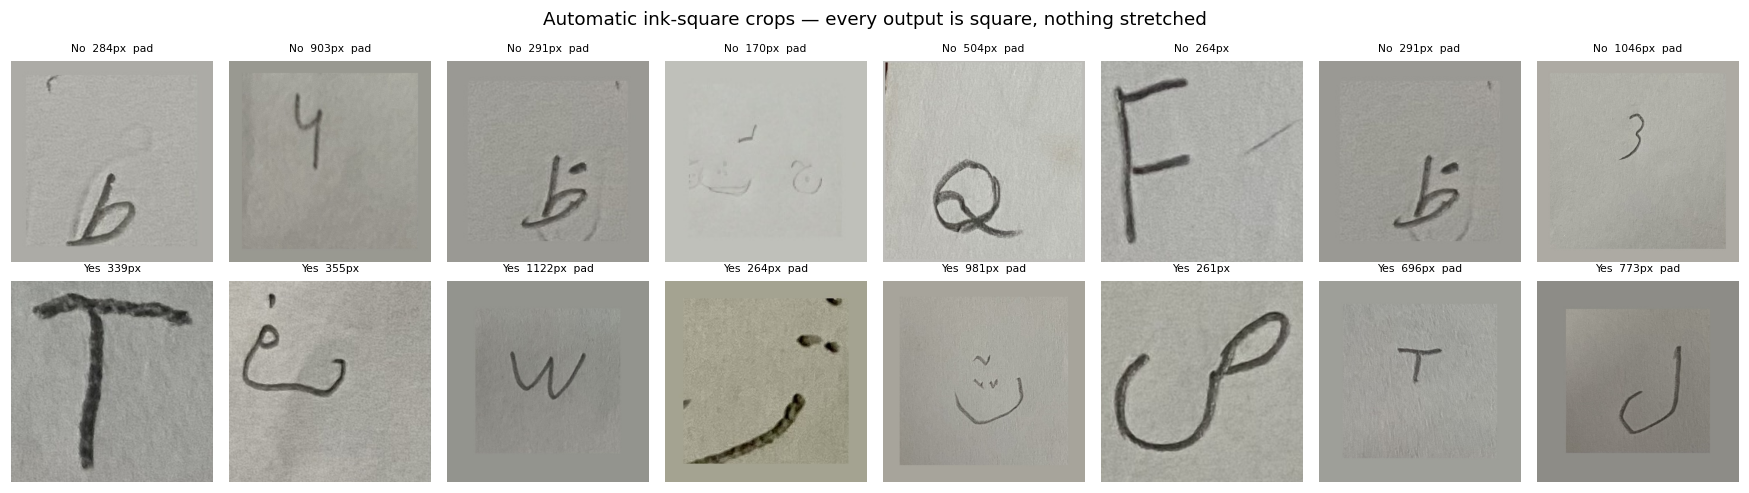

[saved] /content/drive/MyDrive/DyslexAI/results/figures/A_autocrop_samples.png


In [ ]:
fig, axes = plt.subplots(2, 8, figsize=(16, 4.6))
rng3 = np.random.default_rng(SEED)
for row, cls in enumerate(['No', 'Yes']):
    sub = ok[ok['class_label'] == cls]
    pick = rng3.choice(len(sub), 8, replace=False)
    for col, i in enumerate(pick):
        r = sub.iloc[i]
        axes[row, col].imshow(Image.open(r['abs_path']))
        axes[row, col].set_title(f'{cls}  {r["crop_side"]}px'
                                 f'{"  pad" if r["padded"] else ""}', fontsize=7)
        axes[row, col].axis('off')

fig.suptitle('Automatic ink-square crops — every output is square, nothing stretched',
             fontsize=12)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'A_autocrop_samples.png', bbox_inches='tight')
plt.show()
print(f'[saved] {FIGURES_DIR / "A_autocrop_samples.png"}')

---
# STAGE 8 — Report

In [ ]:
report = f"""
{'='*72}
DATASET A - AUTOMATIC INK-SQUARE CROPPING
{'='*72}
Generated : {datetime.now().isoformat(timespec='seconds')}
Jira      : DYS-27 (defect), DYS-28 (this work)
Seed      : {SEED}

--- RULE ---------------------------------------------------------------
  1. ink = greyscale pixels darker than mean - {THRESHOLD_K}*std
     (fallback: darkest 2% if fewer than {MIN_INK_PX} ink pixels)
  2. bounding box of the ink
  3. expand to a SQUARE using real paper, margin {MARGIN:.0%}
  4. pad only where a real-paper square cannot fit

  Deterministic. No human judgement. Identical for both classes.

--- COVERAGE -----------------------------------------------------------
  images processed              : {len(auto)}
  ink found                     : {(auto['status']=='OK').sum()}
  no ink found                  : {(auto['status']!='OK').sum()}
  threshold fallback used       : {(ok['threshold_method']=='percentile_fallback').sum()}

  real-paper square, no padding : {(~ok['padded']).sum()} ({100*(~ok['padded']).mean():.1f}%)
  padding required              : {ok['padded'].sum()} ({100*ok['padded'].mean():.1f}%)
  median pad fraction           : {100*ok[ok.padded]['pad_fraction'].median():.1f}% of square

  DISTORTION AT RESIZE          : 1.00 for every image

--- GEOMETRY-ONLY BASELINE (the decisive test) -------------------------
{geom_df.to_string(index=False)}

  Top single features:
{single_df.head(4).to_string(index=False)}

--- COMPARISON ---------------------------------------------------------
{comparison.to_string(index=False)}

  Baseline CNN (padded, uncropped) : {CNN_BASELINE}
  Chance                            : 0.500

--- RESIDUAL RISK ------------------------------------------------------
  Padding requirement vs class: chi-square p = {p:.4f}
  Included as a feature in the geometry baseline above, so its
  contribution is measured rather than hidden.

--- OUTPUT -------------------------------------------------------------
  dataset_a_autocrop_metadata.csv  {len(auto_meta)} rows
  Autocrop_No.zip, Autocrop_Yes.zip  -> Drive archives/

--- LIMITATIONS --------------------------------------------------------
  * The ink threshold is adaptive per image but the parameters
    (k={THRESHOLD_K}, margin={MARGIN:.0%}) are fixed choices, not optimised.
  * Faint writing may be under-detected; the fallback count above
    indicates how often this occurred.
  * Padding remains necessary for {100*ok['padded'].mean():.0f}% of images and correlates
    with class. Monitored, not eliminated.
  * The manual crops are retained as a comparison arm and are not deleted.
{'='*72}
""".strip()

print(report)
(REPORTS_DIR / 'dataset_a_autocrop_report.txt').write_text(report)
print(f'\n[saved] {REPORTS_DIR / "dataset_a_autocrop_report.txt"}')

DATASET A - AUTOMATIC INK-SQUARE CROPPING
Generated : 2026-09-27T07:11:23
Jira      : DYS-27 (defect), DYS-28 (this work)
Seed      : 42

--- RULE ---------------------------------------------------------------
  1. ink = greyscale pixels darker than mean - 2.0*std
     (fallback: darkest 2% if fewer than 20 ink pixels)
  2. bounding box of the ink
  3. expand to a SQUARE using real paper, margin 15%
  4. pad only where a real-paper square cannot fit

  Deterministic. No human judgement. Identical for both classes.

--- COVERAGE -----------------------------------------------------------
  images processed              : 852
  ink found                     : 852
  no ink found                  : 0
  threshold fallback used       : 0

  real-paper square, no padding : 394 (46.2%)
  padding required              : 458 (53.8%)
  median pad fraction           : 34.2% of square

  DISTORTION AT RESIZE          : 1.00 for every image

--- GEOMETRY-ONLY BASELINE (the decisive test) ----------

---
# Experiment Log

## What we actually did

1. Replaced manual cropping with a deterministic rule: detect the ink, take its bounding box,
   expand to a square using the real paper already in the image.
2. Verified the rule is reproducible — the same image produces the same box on re-run.
3. Confirmed every output is square, so **no image is stretched at any later resize**.
4. Measured how often a real-paper square is possible, and recorded the padded fraction per
   image where it is not.
5. **Trained a geometry-only classifier** on the output and compared it against the same test
   applied to the manual crops.
6. Kept the manual crops as a comparison arm.

## What we learned

*(complete after running)*

- Geometry-only balanced accuracy on automatic crops: ___ (manual crops: 0.707, chance: 0.500)
- Images needing no synthetic padding: ___
- Distortion at resize: 1.00 for every image

## What we can tell

> Manual cropping removed the blank area as requested, but testing showed it introduced a
> stronger artefact: crop geometry alone predicted the class better than our CNN did. Because
> each class was cropped by a different team member, we believe this reflected inconsistent
> annotation rather than handwriting. We replaced it with a deterministic rule that centres a
> square on the detected ink, which removes both the human inconsistency and the distortion,
> and we now measure the geometry-only baseline for every dataset before training on it.

## The practice this establishes

**The geometry-only baseline stays in the pipeline permanently**, including for our own
collected dataset. Any model result is reported against it. A CNN that does not clearly beat a
classifier which never sees a pixel has not demonstrated anything about handwriting.

## Requirement for our own dataset

| Problem here | Requirement |
|---|---|
| Two annotators, one class each, confound aligned with the label | Any manual step must be split across annotators so identity never aligns with a label |
| Manual cropping unreproducible | Preprocessing must be code, with parameters recorded |
| Confound found only because we tested for it | Geometry-only baseline runs before any model, every time |

---



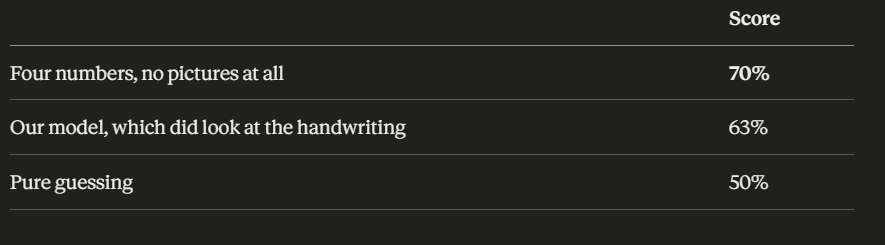

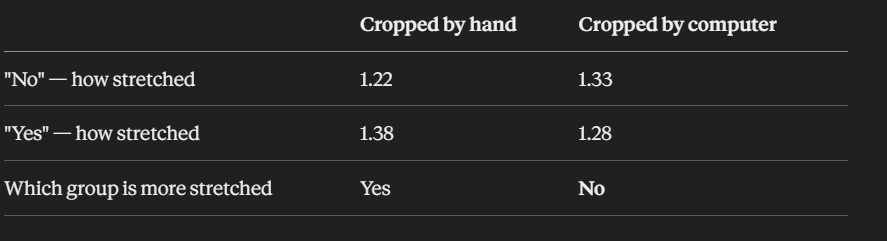